# Combination of Numerical Model and Observations to Improve Machine Learning Predictions in a Chaotic System

This notebook explores how combining sparse, noisy observations, imperfect numerical model outputs can improve the outputs of machine learning model of a chaotic environment using the Lorenz system. 

GitHub Copilot was used to generate part of the code .

The lorenz.yaml file provided alongside the notebook can be used to install the conda environment for running the notebook.

# Notebook Overview
This notebook explores the combination of different data sources to build machine learning models for chaotic systems. The key steps and data sources include:
- **Data Sources**:
  - Ground truth data from the Lorenz system.
  - Sparse and noisy observations sampled from ground truth.
  - Imperfect numerical model outputs.
- **Objective**: Investigate how combining these data sources can improve machine learning predictions.
- **Synthetic Dataset**:
  - Use the Lorenz system to generate synthetic data.
  - Introduce noise and sparsity to simulate real-world scenarios.
  - Create an imperfect numerical model with parameter errors.
- **Data Preparation**:
  - Normalize and preprocess the data.
  - Split the data into training, validation, and test sets.
- **Modeling**:
  - Train either a simple dense neural network or a LSTM using individual and combined data sources.
  - Evaluate model performance on unseen data from a common test dataset.
- **Visualization and Analysis**:
  - Plot loss functions to understand training dynamics.
  - Compare predictions from different models against ground truth.
This exercise demonstrates the benefits of combining diverse data sources for machine learning in chaotic systems.

# 1. Import Required Libraries

Import libraries such as NumPy, SciPy, Matplotlib, TensorFlow/PyTorch, and others for numerical modeling, data processing, and machine learning.  

In [1]:
# Import Required Libraries
import os
import random
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Set all random seeds BEFORE importing TensorFlow
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Configure TensorFlow for deterministic behavior
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
tf.random.set_seed(SEED)
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

# Note: Using 42 as SEED for reproducibility.

I0000 00:00:1782830752.318496  272217 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782830762.681860  272217 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1782830767.707550  272217 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import platform
import numpy as np
import scipy
import matplotlib
import sklearn
import tensorflow as tf

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

Python: 3.11.15
NumPy: 2.4.6
SciPy: 1.17.1
Matplotlib: 3.11.0
scikit-learn: 1.9.0
TensorFlow: 2.21.0


# 2. Simulate the Ground Truth System (Lorenz System)

Use an accurate ODE solver to simulate the Lorenz system and generate reference data for the chaotic environment.

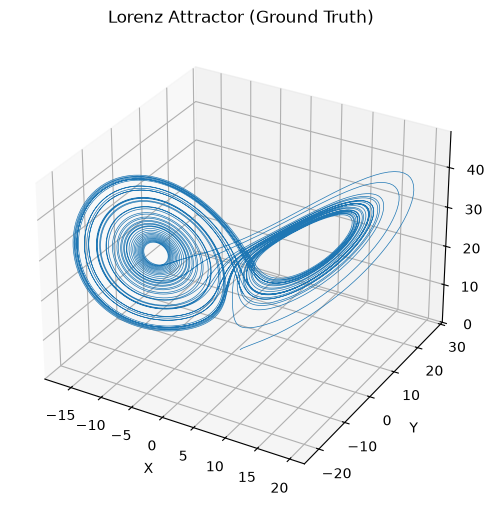

In [3]:
# Define the Lorenz system
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the Lorenz system
t_span = (0, 50)  # Time range
initial_state = [1.0, 1.0, 1.0]  # Initial conditions
t_eval = np.linspace(t_span[0], t_span[1], 10000)  # Time points for evaluation

solution = solve_ivp(lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
t = solution.t
x, y, z = solution.y

# Plot the Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.5)
ax.set_title("Lorenz Attractor (Ground Truth)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 3. Create the Imperfect Numerical Model

Question 1 : How can we create an imperfect numerical model of the Lorenz system? 

Imperfect model can be created introducing parameter errors or reducing resolution. In this case we try using the parameters sigma=12.0, rho=25.0, beta=2.5 and observe the differences in the system's behavior.

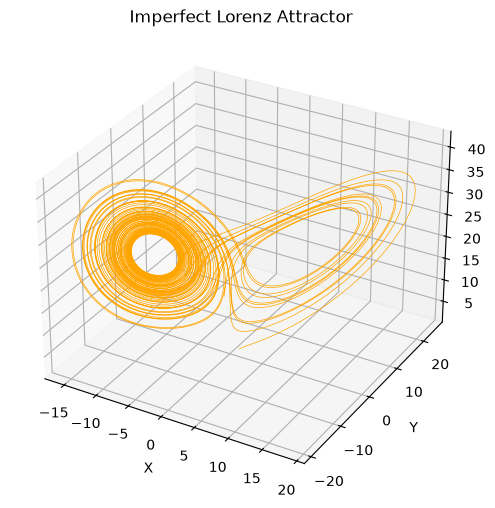

In [4]:
# Define an imperfect Lorenz system with parameter errors
def imperfect_lorenz_system(t, state, sigma=12.0, rho=25.0, beta=2.5):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Simulate the imperfect Lorenz system
imperfect_solution = solve_ivp(imperfect_lorenz_system, t_span, initial_state, t_eval=t_eval)

# Extract the solution
x_imp, y_imp, z_imp = imperfect_solution.y

# Plot the imperfect Lorenz attractor
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x_imp, y_imp, z_imp, lw=0.5, color='orange')
ax.set_title("Imperfect Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# 4. Generate Sparse and Noisy Observations

Question 2: How can we generate sparse and noisy observations from the ground truth data? 

Consider sampling the data sparsely and adding noise to mimic real-world measurement limitations. Think about the number of samples to take and the level of noise to introduce.

In the example proposed, a subset of the ground truth data is selected by randomly sampling 500 indices to create sparse observations. Then, Gaussian noise with a mean of 0 and a standard deviation of 2.0 was added to the x, y, and z coordinates of the sampled data points. This process simulates real-world scenarios where measurements are both limited and noisy.

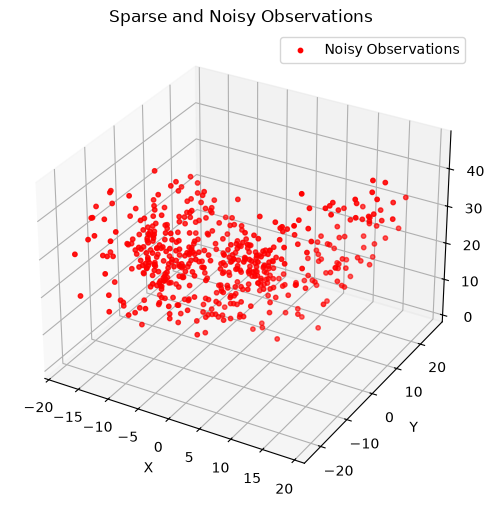

In [5]:
# Generate sparse and noisy observations

num_samples = 500  # Number of sparse samples
indices = sorted(random.sample(range(len(t)), num_samples))  # Randomly select indices
t_sparse = t[indices]
x_sparse = x[indices] + np.random.normal(0, 2.0, num_samples)  # Add noise
y_sparse = y[indices] + np.random.normal(0, 2.0, num_samples)
z_sparse = z[indices] + np.random.normal(0, 2.0, num_samples)

# Plot sparse and noisy observations
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(x_sparse, y_sparse, z_sparse, c='red', s=10, label='Noisy Observations')
ax.set_title("Sparse and Noisy Observations")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

# 5. Build Machine Learning Models to Predict the Lorenz System

Question 3: How can we build and train machine learning models to predict the Lorenz system?

Try using different data sources such as ground truth, sparse observations, imperfect numerical model outputs, or a combination of the sources. Consider how to define the model architecture, preprocess the data, and evaluate the model's performance.

The Lorenz system generates sequential data with temporal dependencies. This notebook supports both an LSTM and a simple dense neural network so the user can choose which one to train.

In [6]:
# Import additional libraries for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Define the model builder
# The dense option mirrors the simple feed-forward network in utilities.py
# and uses only the last state in each sequence as input.
def build_model(model_architecture, sequence_length, cc_activation='tanh'):
    from tensorflow.keras import Input
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense

    if model_architecture == 'lstm':
        input_shape = (sequence_length, 3)
        model = Sequential([
            Input(shape=input_shape),
            LSTM(64, activation=cc_activation, return_sequences=True),
            LSTM(64, activation=cc_activation),
            Dense(3)  # Predict x, y, z
        ])
        cc_in_typ_mod = 'Sequence'
    elif model_architecture == 'dense':
        input_shape = (3,)
        model = Sequential([
            Input(shape=input_shape),
            Dense(8, activation=cc_activation),
            Dense(16, activation=cc_activation),
            Dense(8, activation=cc_activation),
            Dense(3)  # Predict x, y, z
        ])
        cc_in_typ_mod = 'Vector'
    else:
        raise ValueError("model_architecture must be 'lstm' or 'dense'")

    model.compile(optimizer='adam', loss='mse')
    return model, cc_in_typ_mod


# Helper function to create sequences for time-series prediction (LSTM only)
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)


# Helper function to create single states for Dense NN models
# Each sample is just a single state paired with the next state
def create_dense_inputs(data):
    X, y = [], []
    for i in range(len(data) - 1):
        X.append(data[i])                     # single state vector
        y.append(data[i + 1])                 # next state vector
    return np.array(X), np.array(y)

In [7]:
# Define sequence_length for LSTM models (ONLY used when model_architecture == 'lstm')
# For Dense models, single states are used instead, so sequence_length is ignored
sequence_length = 50  # 

# 5.1 Preprocessing : Normalize the data
Normalization ensures that all features are on a similar scale, improving model training and convergence.
It also prevents features with larger scales from dominating the learning process.

In [8]:
scaler = MinMaxScaler()
ground_truth_scaled = scaler.fit_transform(np.column_stack((x, y, z)))
imperfect_scaled = scaler.transform(np.column_stack((x_imp, y_imp, z_imp)))
observations_scaled = scaler.transform(np.column_stack((x_sparse, y_sparse, z_sparse)))

# 5.2 Split the data in training, validation, and test sets

Create a function that splits the data into training (70%) validation (15%) and test (15%)

In [10]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
def split_data(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
    X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)



# 5.3 Training the models

In this section we will create:

a model based on observations only

a model based on imperfect model and ground truth

a model based on imperfect numerical model and sparse observations

Set `model_architecture` to `'lstm'` or `'dense'` in the next cell to choose which model family is trained. in this example we use 'dense'

In [11]:
# Choose the model architecture to train: 'dense' or 'lstm'
model_architecture = 'dense'  
print(f'Training architecture: {model_architecture}')

Training architecture: dense


In [12]:
# Model based on observations only
# Prepare data sets for training
if model_architecture == 'lstm':
    X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
else:  # dense
    X_obs, y_obs = create_dense_inputs(observations_scaled)

# Split the datasets
(X_obs_train, y_obs_train), (X_obs_val, y_obs_val), (X_obs_test, y_obs_test) = split_data(X_obs, y_obs)
# Train the model using only observations
print(f"Training model with only observations using the {model_architecture} architecture...")
model_obs, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_obs = model_obs.fit(X_obs_train, y_obs_train, validation_data=(X_obs_val, y_obs_val), epochs=20, batch_size=32, verbose=1)

Training model with only observations using the dense architecture...
Epoch 1/20


E0000 00:00:1782831125.974590  272217 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1604 - val_loss: 0.1265
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0628 - val_loss: 0.0559
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0331 - val_loss: 0.0327
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0242 - val_loss: 0.0278
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0223 - val_loss: 0.0284
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0211 - val_loss: 0.0280
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0199 - val_loss: 0.0276
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0191 - val_loss: 0.0271
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0185 - val_loss: 0.0267
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180 - val_loss: 0.0264
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 - val_loss: 0.0261
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0172 - val_loss: 0.026

In [13]:
# Model based on combination of ground truth and imperfect model
# Prepare datasets for training
if model_architecture == 'lstm':
    X_ground_truth, y_ground_truth = create_sequences(ground_truth_scaled, sequence_length)
    X_imperfect, y_imperfect = create_sequences(imperfect_scaled, sequence_length)
else:  # dense
    X_ground_truth, y_ground_truth = create_dense_inputs(ground_truth_scaled)
    X_imperfect, y_imperfect = create_dense_inputs(imperfect_scaled)

X_combined = np.concatenate((X_ground_truth, X_imperfect), axis=0)
y_combined = np.concatenate((y_ground_truth, y_imperfect), axis=0)
# Split the datasets
(X_combined_train, y_combined_train), (X_combined_val, y_combined_val), (X_combined_test, y_combined_test) = split_data(X_combined, y_combined)
# Train the model using imperfect model and ground truth sources combined
print(f"Training model with imperfect model and ground truth sources combined using the {model_architecture} architecture...")
model_combined, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_combined = model_combined.fit(X_combined_train, y_combined_train, validation_data=(X_combined_val, y_combined_val), epochs=20, batch_size=32, verbose=1)

Training model with imperfect model and ground truth sources combined using the dense architecture...
Epoch 1/20


E0000 00:00:1782831142.442263  272217 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0047 - val_loss: 3.9771e-04
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9457e-04 - val_loss: 1.9604e-04
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7183e-04 - val_loss: 1.4463e-04
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9779e-04 - val_loss: 9.9431e-05
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4402e-04 - val_loss: 7.1368e-05
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0566e-04 - val_loss: 5.1995e-05
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.6517e-05 - val_loss: 3.4447e-05
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5903e-05 - val_loss: 2.3344e-05
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.1995e-05 - val_loss: 1.7492e-05
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1840e-05 - val_loss: 1.2337e-05
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3693e-05 - 

In [14]:
# Model based on combination of imperfect numerical model and sparse observations
# Prepare datasets based on model architecture
if model_architecture == 'lstm':
    X_imperfect, y_imperfect = create_sequences(imperfect_scaled, sequence_length)
    X_obs, y_obs = create_sequences(observations_scaled, sequence_length)
else:  # dense
    X_imperfect, y_imperfect = create_dense_inputs(imperfect_scaled)
    X_obs, y_obs = create_dense_inputs(observations_scaled)

# Combine imperfect numerical model and sparse observations
X_combined_obs_num = np.concatenate((X_imperfect, X_obs), axis=0)
y_combined_obs_num = np.concatenate((y_imperfect, y_obs), axis=0)

# Split the combined dataset
(X_combined_obs_num_train, y_combined_obs_num_train),(X_combined_obs_num_val, y_combined_obs_num_val),(X_combined_obs_num_test, y_combined_obs_num_test) = split_data(X_combined_obs_num, y_combined_obs_num)

# Train the model using imperfect numerical model and sparse observations
print(f"Training model with imperfect numerical model and sparse observations using the {model_architecture} architecture...")
model_combined_obs_num, cc_in_typ_mod = build_model(model_architecture, sequence_length)
history_combined_obs_num = model_combined_obs_num.fit(
    X_combined_obs_num_train, y_combined_obs_num_train,
    validation_data=(X_combined_obs_num_val, y_combined_obs_num_val),
    epochs=20, batch_size=32, verbose=1)

Training model with imperfect numerical model and sparse observations using the dense architecture...
Epoch 1/20


E0000 00:00:1782831175.929863  272217 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0154 - val_loss: 0.0069
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020 - val_loss: 0.0032
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.4193e-04 - val_loss: 9.8982e-04
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.9970e-04 - val_loss: 4.2210e-04
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8979e-04 - val_loss: 2.8327e-04
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4748e-04 - val_loss: 2.2925e-04
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2344e-04 - val_loss: 1.9987e-04
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0629e-04 - val_loss: 1.7751e-04
Epoch 9/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.2930e-05 - val_loss: 1.5229e-04
Epoch 10/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.2117e-05 - val_loss: 1.3068e-04
Epoch 11/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.3155e-05 - val_loss: 1.

# 6. Analyse the training and validation loss curves.

Question 4: Can you plot the loss function of the models?

Think about how the loss function evolves over epochs. What can we understand about the training process and the performance of the models from the loss curves? 

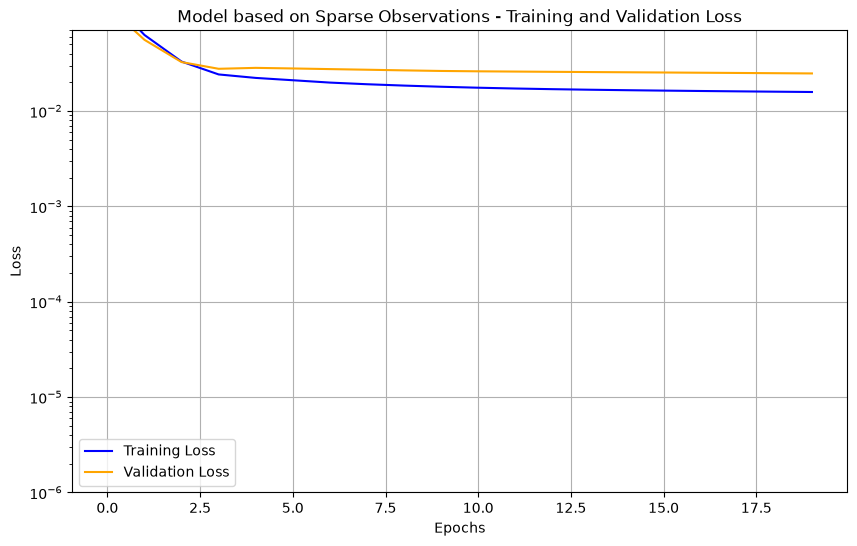

In [15]:
# Plot the loss function for the model trained on sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_obs.history['loss'], label='Training Loss', color='blue')
plt.plot(history_obs.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model based on Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

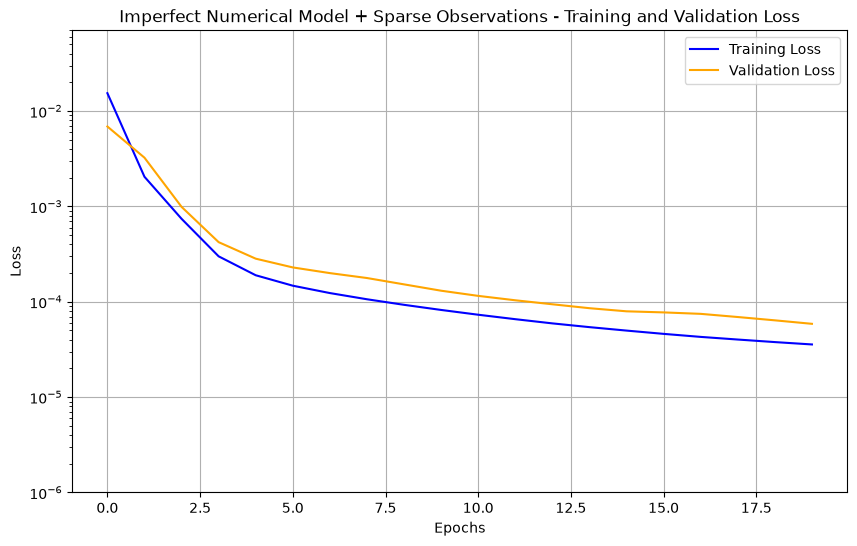

In [16]:
# Plot the loss function for the model trained on imperfect numerical model and sparse observations
plt.figure(figsize=(10, 6))
plt.plot(history_combined_obs_num.history['loss'], label='Training Loss', color='blue')
plt.plot(history_combined_obs_num.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Imperfect Numerical Model + Sparse Observations - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

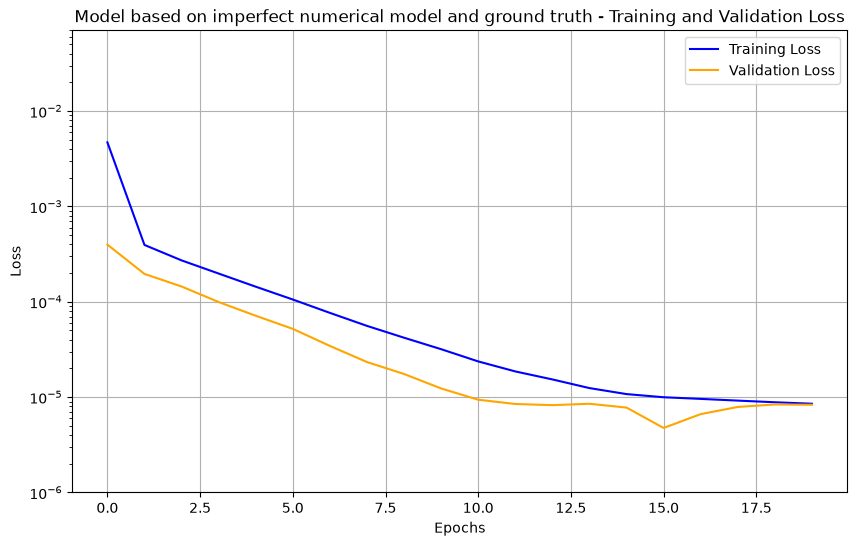

In [17]:
# Plot the loss function for the model trained on ground truth and imperfect numerical model combined
plt.figure(figsize=(10, 6))
plt.plot(history_combined.history['loss'], label='Training Loss', color='blue')
plt.plot(history_combined.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model based on imperfect numerical model and ground truth - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.ylim(1e-6, 7e-2)  # Adjusted consistent y-axis range for log scale
plt.legend()
plt.grid(True)
plt.show()

In [18]:
history_combined.history['val_loss']



[0.000397712952690199,
 0.00019603880355134606,
 0.00014462856051977724,
 9.943074110196903e-05,
 7.136753265513107e-05,
 5.1994549721712247e-05,
 3.444675530772656e-05,
 2.334440068807453e-05,
 1.74921424331842e-05,
 1.2336538929957896e-05,
 9.393892469233833e-06,
 8.477082701574545e-06,
 8.238034752139356e-06,
 8.521933523297776e-06,
 7.77255445427727e-06,
 4.752692348120036e-06,
 6.63642003928544e-06,
 7.890268534538336e-06,
 8.382316991628613e-06,
 8.31968463899102e-06]

# Evaluate All Models on a Common Test Dataset

Question 5: Can we use the models to make a prediction on unseen data ?  We will use the models to predict unseen data from the test dataset. To ensure a fair comparison,we create a common test dataset derived only from the test portion of the ground truth data, avoiding overlap with training and validation data.

In [19]:
# Split the ground truth data into training, validation, and test sets
(X_ground_truth_train, y_ground_truth_train), \
(X_ground_truth_val, y_ground_truth_val), \
(X_ground_truth_test, y_ground_truth_test) = split_data(ground_truth_scaled, ground_truth_scaled, train_ratio=0.7, val_ratio=0.15)

# Create sequences for the test set based on model architecture
if model_architecture == 'lstm':
    X_common_test, y_common_test = create_sequences(X_ground_truth_test, sequence_length)
else:  # dense
    X_common_test, y_common_test = create_dense_inputs(X_ground_truth_test)

In [20]:
# Recompute predictions for the common test dataset
y_pred_obs = model_obs.predict(X_common_test, verbose=0)
y_pred_combined = model_combined.predict(X_common_test, verbose=0)
y_pred_combined_obs_num = model_combined_obs_num.predict(X_common_test, verbose=0)

E0000 00:00:1782831298.760941  272217 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


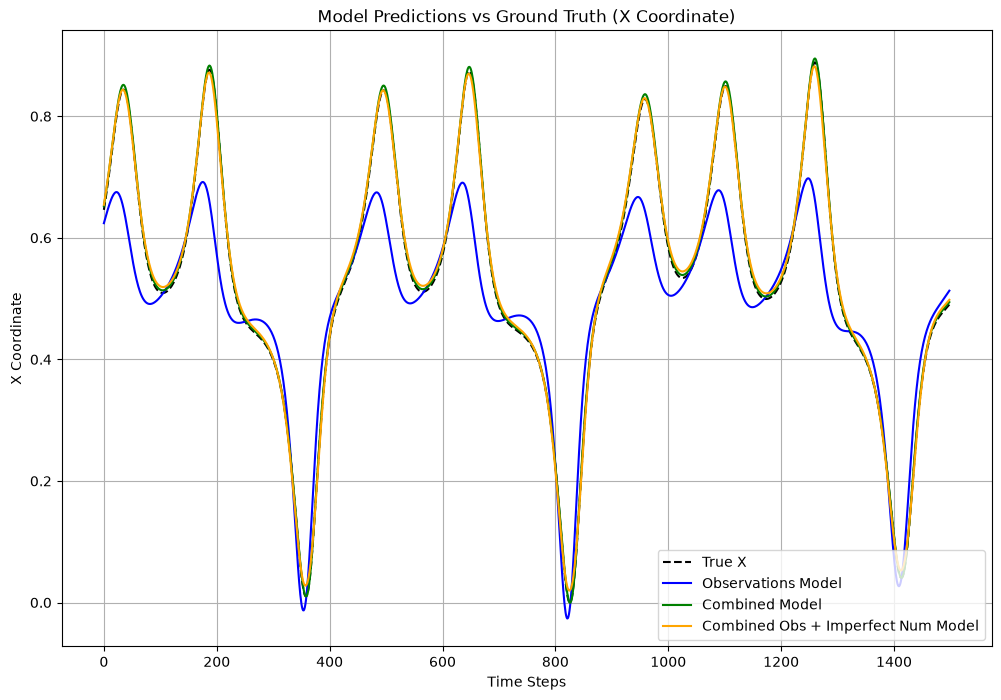

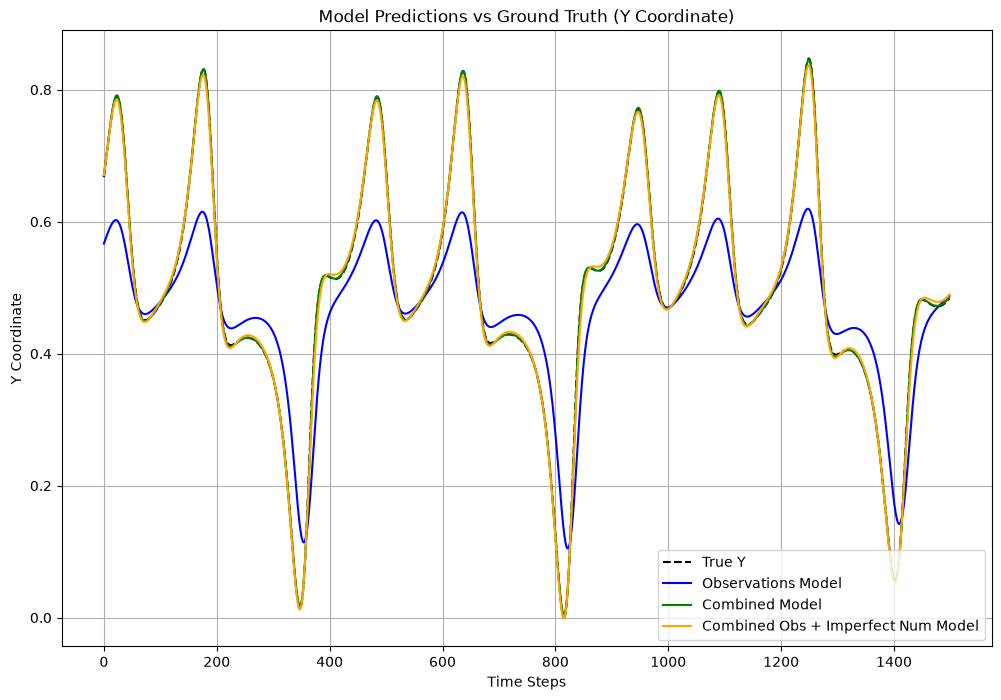

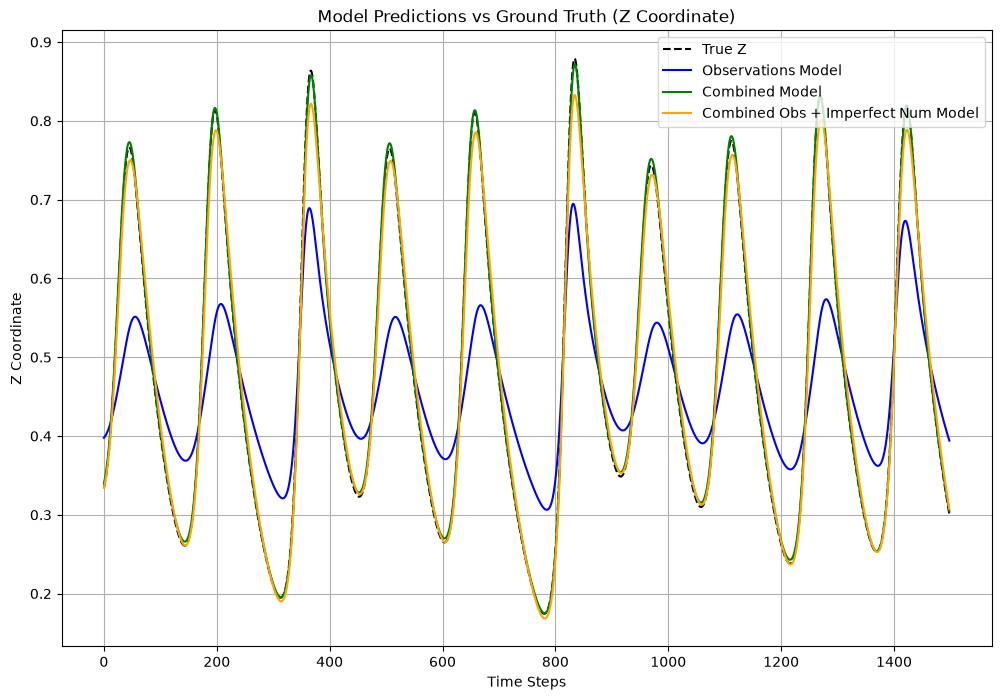

In [21]:


# Visualize predictions vs ground truth for the common test dataset (X Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 0], label='True X', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 0], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 0], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 0], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (X Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('X Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Y Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 1], label='True Y', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 1], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 1], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 1], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Y Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# Visualize predictions vs ground truth for the common test dataset (Z Coordinate)
plt.figure(figsize=(12, 8))

# Plot ground truth
plt.plot(y_common_test[:, 2], label='True Z', color='black', linestyle='dashed')

# Plot predictions
plt.plot(y_pred_obs[:, 2], label='Observations Model', color='blue')
plt.plot(y_pred_combined[:, 2], label='Combined Model', color='green')
plt.plot(y_pred_combined_obs_num[:, 2], label='Combined Obs + Imperfect Num Model', color='orange')

plt.title('Model Predictions vs Ground Truth (Z Coordinate)')
plt.xlabel('Time Steps')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True)
plt.show()

# What we learned:

Simulating Chaotic Systems: The Lorenz system demonstrates how to generate synthetic data for chaotic environments.

Choice of Architecture: LSTMs and simple dense networks can be used for capturing temporal dependencies in time-series data. 

Data Preprocessing: Normalization and scaling of data are essential for improving model training and convergence.

Dataset Splitting: Splitting data into training, validation, and test sets ensures fair evaluation and prevent data leakage.

Combining Data Sources: Using diverse data sources, such as ground truth, sparse observations, and imperfect numerical models, to build different models.

Evaluating Loss Functions: Analysing training and validation loss curves helps in understanding model performance.

Make predictions on unseen data : the test data can be used to make predictions on unseen data.


# Limitations

The notebook can be tested to use two different architectures : LSTM and a simple dense neural network option for comparison. That model is lighter and easier to train, but it does not use the full sequence context in the same way as the LSTM. Long Short-Term Memory (LSTM) networks are well-suited for time-series prediction tasks, particularly in capturing temporal dependencies in sequential data (Hochreiter and Schmidhuber, 1997). 

However, LSTM can struggle with very long-term dependencies and require significant computational resources. Additionally, careful tuning of hyperparameters is essential for optimal performance. Alternative architectures, such as Transformers, may outperform LSTMs in certain scenarios. This notebook is intended as a demonstration of combining diverse data sources to improve machine learning predictions in chaotic systems. The focus is on illustrating the methodology rather than achieving state-of-the-art performance.

References:
1. Lorenz, E. N. (1963). Deterministic nonperiodic flow. Journal of the Atmospheric Sciences, 20(2), 130-141.
2. Hochreiter, Sepp, and Jürgen Schmidhuber (1997). "Long Short-Term Memory." Neural Computation 9(8), 1735–80. DOI:10.1162/neco.1997.9.8.1735

    